# How Close Is HARK's Infinite-Horizon Solution?

HARK finds the infinite-horizon solution of a consumption problem as the limit of finite-horizon solutions. It starts from the last period of life, in which the consumer spends everything, and works backward one period at a time. It stops when the solutions from two successive iterations differ by less than the consumer's `tolerance`, $10^{-6}$ by default, or after 5000 iterations, whichever comes first ([econ-ark/HARK#1847](https://github.com/econ-ark/HARK/issues/1847)).

The perfect foresight model of [Consumption Under Perfect Foresight and CRRA Utility](https://intertemporal-choice.github.io/content/consumption/perfforesightcrra) has a closed-form solution at every horizon. So this notebook can measure exactly how far HARK's infinite-horizon solution is from the true one, and see when, and why, the iteration stops short.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from HARK.ConsumptionSaving.ConsIndShockModel import (PerfForesightConsumerType, calc_human_wealth,
                                                     calc_mpc_min)

plt.style.use("seaborn-v0_8-darkgrid")

## The exact solution at every horizon

The consumer has relative risk aversion $\rho$, discount factor $\beta$, interest factor $R$ and permanent income growth factor $G$. With $T$ periods left after this one, the marginal propensity to consume out of total wealth is

$$\kappa_T = \frac{1-\textbf{Þ}_R}{1-\textbf{Þ}_R^{T+1}}, \qquad \textbf{Þ}_R = \frac{(R\beta)^{1/\rho}}{R},$$

where $\textbf{Þ}_R$ is the return patience factor. Human wealth, the present value of income from next period on relative to this period's permanent income, is

$$h_T = \sum_{n=1}^{T} (G/R)^n,$$

where $G/R$ is the finite human wealth factor. As $T$ grows, they approach $\kappa = 1-\textbf{Þ}_R$ and $h = G/(R-G)$, provided each factor is below 1: that is the [return impatience condition](https://intertemporal-choice.github.io/content/consumption/perfforesightcrra#eq-patr) (RIC) and the [finite human wealth condition](https://intertemporal-choice.github.io/content/consumption/perfforesightcrra#eq-fhwcpf) (FHWC).

In [2]:
def mpc_exact(rho, beta, R, T=np.inf):
    """The MPC with T periods left; T = inf gives the infinite-horizon MPC."""
    thorn_R = (R * beta) ** (1 / rho) / R
    return (1 - thorn_R) / (1 - thorn_R ** (T + 1))


def h_exact(R, G, T=np.inf):
    """Human wealth with T periods left; T = inf gives the infinite-horizon value."""
    return (G / R) * (1 - (G / R) ** T) / (1 - G / R)


def solve_hark(rho, beta, R, G, horizon=None, tol=1e-6):
    """HARK's solution for this period, with `horizon` periods left after it (None: forever)."""
    agent = PerfForesightConsumerType(CRRA=rho, DiscFac=beta, Rfree=[R], PermGroFac=[G], LivPrb=[1.0],
                                      cycles=0 if horizon is None else horizon, tolerance=tol)
    agent.solve()
    return agent.solution[0]

At any finite horizon, HARK's solution is exact. Its MPC (`MPCmin`) and human wealth (`hNrm`) match the formulas:

In [3]:
rho, beta, R, G = 2.5, 0.96, 1.03, 1.01

for T in (1, 5, 25, 100):
    sol = solve_hark(rho, beta, R, G, horizon=T)
    print(f"T = {T:3}:  MPC {sol.MPCmin:.6f}, exact {mpc_exact(rho, beta, R, T):.6f};  "
          f"human wealth {sol.hNrm:.4f}, exact {h_exact(R, G, T):.4f}")

T =   1:  MPC 0.508515, exact 0.508515;  human wealth 0.9806, exact 0.9806
T =   5:  MPC 0.181175, exact 0.181175;  human wealth 4.7162, exact 4.7162
T =  25:  MPC 0.056999, exact 0.056999;  human wealth 19.5689, exact 19.5689
T = 100:  MPC 0.034599, exact 0.034599;  human wealth 43.3927, exact 43.3927


HARK has the pieces of this calculation itself. A consumer's `check_conditions` method computes the patience factors and the infinite-horizon limits, and stores them in its `bilt` dictionary. There, `hNrm` counts this period's income too, so it is $h + 1$. And HARK's solver builds each period's solution from the next period's with `calc_mpc_min` and `calc_human_wealth`, one step of the recursion that gives $\kappa_T$ and $h_T$. Starting from the last period and taking 100 steps by hand gives the solution with 100 periods left:

In [4]:
agent = PerfForesightConsumerType(CRRA=rho, DiscFac=beta, Rfree=[R], PermGroFac=[G], LivPrb=[1.0], cycles=0)
agent.check_conditions()
thorn_R = agent.bilt["RPFac"]
print(f"return patience factor {thorn_R:.4f}, finite human wealth factor {agent.bilt['FHWFac']:.4f}")
print(f"limits: MPC {agent.bilt['MPCmin']:.6f}, exact {mpc_exact(rho, beta, R):.6f};  "
      f"human wealth {agent.bilt['hNrm'] - 1:.4f}, exact {h_exact(R, G):.4f}")

mpc, h = 1.0, 0.0  # the last period: spend everything, with no income to come
for T in range(100):
    mpc, h = calc_mpc_min(mpc, thorn_R), calc_human_wealth(h, G, R, 1.0)
print(f"100 steps: MPC {mpc:.6f}, exact {mpc_exact(rho, beta, R, 100):.6f};  "
      f"human wealth {h:.4f}, exact {h_exact(R, G, 100):.4f}")

return patience factor 0.9665, finite human wealth factor 0.9806
limits: MPC 0.033490, exact 0.033490;  human wealth 50.5000, exact 50.5000
100 steps: MPC 0.034599, exact 0.034599;  human wealth 43.3927, exact 43.3927


## Convergence is geometric

Each further period of backward iteration shrinks the distance of human wealth from its limit by the factor $G/R$ exactly, and the distance of the MPC from its limit by a factor that approaches $\textbf{Þ}_R$. On a log scale the distances fall along straight lines:

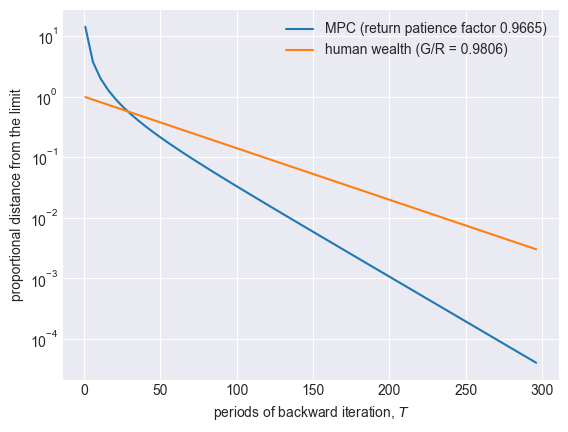

In [5]:
horizons = np.arange(1, 301, 5)
sols = [solve_hark(rho, beta, R, G, horizon=T) for T in horizons]
kappa, h = mpc_exact(rho, beta, R), h_exact(R, G)

plt.semilogy(horizons, [s.MPCmin / kappa - 1 for s in sols], label=f"MPC (return patience factor {thorn_R:.4f})")
plt.semilogy(horizons, [1 - s.hNrm / h for s in sols], label=f"human wealth (G/R = {G / R:.4f})")
plt.xlabel("periods of backward iteration, $T$")
plt.ylabel("proportional distance from the limit")
plt.legend()
plt.show()

The factors whose being below 1 is the RIC and the FHWC therefore also set how fast backward iteration converges: the closer a factor is to 1, the more iterations the solution needs.

## A small change does not mean a small error

HARK stops when two successive solutions differ by less than `tolerance`. If the distance from the limit shrinks by a factor $\textbf{Þ}$ each iteration, a last change of $d$ leaves a remaining distance of about $d\,\textbf{Þ}/(1-\textbf{Þ})$, which is many times $d$ when $\textbf{Þ}$ is close to 1. With $\rho > 1$, the return patience factor $\textbf{Þ}_R$ approaches 1 only when $\beta$ exceeds 1, approaching $R^{\rho-1}$. Here is the error in HARK's infinite-horizon MPC as $\beta$ rises toward that value, for three tolerances:

tolerance 1e-06: MPC overstated by 151.7 percent at beta = 1.044


tolerance 1e-09: MPC overstated by 8.4 percent at beta = 1.044


tolerance 1e-12: MPC overstated by 8.4 percent at beta = 1.044


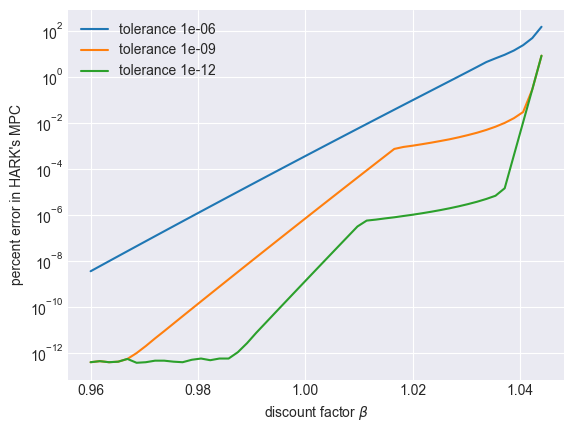

In [6]:
betas = np.linspace(0.96, 1.044, 50)  # the RIC fails at beta = R**(rho - 1) = 1.0453

for tol in (1e-6, 1e-9, 1e-12):
    errors = [100 * (solve_hark(rho, b, R, G, tol=tol).MPCmin / mpc_exact(rho, b, R) - 1) for b in betas]
    plt.semilogy(betas, errors, label=f"tolerance {tol:g}")
    print(f"tolerance {tol:g}: MPC overstated by {errors[-1]:.1f} percent at beta = {betas[-1]}")
plt.xlabel(r"discount factor $\beta$")
plt.ylabel("percent error in HARK's MPC")
plt.legend()
plt.show()

HARK measures the change between iterations in both points that define its consumption function: where the function starts, at $m = -h$, which moves with human wealth, and its slope, the MPC. It stops only when both have settled. At the lower values of $\beta$, human wealth is the slower to settle, so it decides when HARK stops, after $\log(\text{tolerance})/\log(G/R)$ iterations (1057 at a tolerance of $10^{-9}$), and by then the MPC is far closer than the tolerance. The kinks are where the MPC becomes the slower and takes over. The floor of the $10^{-12}$ curve is the precision of floating-point arithmetic.

## The limit of 5000 iterations

Tightening the tolerance helps until HARK's limit of 5000 iterations binds. From then on its solution is the one with 5000 periods left, whatever the tolerance: at $\beta = 1.044$, where $\textbf{Þ}_R^{5000} \approx 0.08$, its MPC is $\kappa_{5000}$, about 8 percent above $\kappa$, even at a tolerance of $10^{-12}$.

Human wealth converges by the factor $G/R$, which involves neither $\beta$ nor $\rho$. When $G/R$ is close to 1, the limit binds for it too:

In [7]:
for G_near in (1.02, 1.029, 1.0295):
    sol = solve_hark(rho, beta, R, G_near, tol=1e-12)
    print(f"G = {G_near}: HARK's human wealth {sol.hNrm:.0f}, exact {h_exact(R, G_near):.0f}")

G = 1.02: HARK's human wealth 102, exact 102


G = 1.029: HARK's human wealth 1021, exact 1029


G = 1.0295: HARK's human wealth 1877, exact 2059


## The lesson

HARK's backward iteration is exact at every finite horizon. Its only error is stopping too soon, which matters when a factor that governs convergence is close to 1. There, tighten `tolerance`, and wherever the model has closed forms, check the numerical solution against them.